# Inferencia en CPU — modelos entrenados (clasificación + detección)

Este notebook demuestra que los **dos modelos** del proyecto funcionan **sin GPU**:

1. **Clasificador** — MobileNetV3-Small (mejor modelo del experimento:
   F1 = 1.0000 en test, 1.5M parámetros), cargado con `map_location="cpu"`.
2. **Detector** — YOLOv8n, cargado desde `outputs/yolo/train/weights/best.pt`
   y forzado a `device="cpu"` (el equivalente de `map_location="cpu"` en la API
   de Ultralytics).

Ambos corren inferencia sobre las imágenes de `Imagenes_de_prueba/`
(junto al notebook) y visualizan el resultado.

No requiere CUDA ni MPS: todo se ejecuta en el procesador.

## 1. Configuración e imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

# Rutas relativas: el notebook vive en notebooks/ dentro del repositorio.
ROOT = Path("..").resolve()

# Se reutiliza exactamente la misma lógica del entrenamiento (src/common.py).
sys.path.insert(0, str(ROOT / "src"))

from common import (  # noqa: E402
    IMAGENET_MEAN,
    IMAGENET_STD,
    load_checkpoint,
    make_eval_transform,
)

# Se fuerza CPU explícitamente, aunque haya GPU disponible.
DEVICE = torch.device("cpu")

CHECKPOINT_PATH = (
    ROOT / "outputs" / "checkpoints" / "mobilenet_v3_small_best.pt"
)
PRUEBAS_DIR = ROOT / "notebooks" / "Imagenes_de_prueba"

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Dispositivo de inferencia:", DEVICE)

PyTorch: 2.13.0+cpu
CUDA disponible: False
Dispositivo de inferencia: cpu


## 2. Carga del modelo entrenado

El checkpoint se carga con `map_location="cpu"`, por lo que un modelo
entrenado en GPU se puede usar en cualquier máquina sin GPU.

In [2]:
model, checkpoint = load_checkpoint(CHECKPOINT_PATH, DEVICE)

CLASS_NAMES = checkpoint["class_names"]
IMG_SIZE = checkpoint["img_size"]

print("Modelo:", checkpoint["model_name"])
print("Clases:", CLASS_NAMES)
print("Métricas de validación guardadas en el checkpoint:")
for nombre, valor in checkpoint["metrics"].items():
    print(f"  {nombre}: {valor:.4f}")

Modelo: mobilenet_v3_small
Clases: ['crack', 'hole', 'normal', 'rust', 'scratch']
Métricas de validación guardadas en el checkpoint:
  accuracy: 1.0000
  f1_macro: 1.0000
  f1_weighted: 1.0000


## 3. Inferencia sobre imágenes de test

Se toman las 12 imágenes de `notebooks/Imagenes_de_prueba/` y se
clasifican en CPU. La clase real se deriva del prefijo del nombre de
archivo (`{clase}_NNNNN.png`).

In [3]:
transform = make_eval_transform(IMG_SIZE)

# La clase real es el prefijo del nombre de archivo ({clase}_NNNNN.png).
muestras = [
    (ruta.name.split("_")[0], ruta)
    for ruta in sorted(PRUEBAS_DIR.glob("*.png"))
]

print(f"Imágenes de prueba: {len(muestras)}")

Imágenes de prueba: 12


In [4]:
@torch.no_grad()
def predecir(ruta_imagen):
    img = Image.open(ruta_imagen)
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    probs = torch.softmax(model(tensor), dim=1).numpy()[0]
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx]), img


resultados = []
for real, ruta in muestras:
    prediccion, confianza, img = predecir(ruta)
    resultados.append({
        "ruta": ruta,
        "real": real,
        "prediccion": prediccion,
        "confianza": confianza,
        "imagen": img,
    })
    marca = "OK" if prediccion == real else "ERROR"
    print(
        f"{ruta.name:22s} real={real:8s} "
        f"prediccion={prediccion:8s} confianza={confianza:.3f} [{marca}]"
    )

crack_00115.png        real=crack    prediccion=crack    confianza=1.000 [OK]
crack_00130.png        real=crack    prediccion=crack    confianza=1.000 [OK]
crack_00136.png        real=crack    prediccion=crack    confianza=1.000 [OK]
hole_00126.png         real=hole     prediccion=hole     confianza=1.000 [OK]
hole_00127.png         real=hole     prediccion=hole     confianza=1.000 [OK]
hole_00185.png         real=hole     prediccion=hole     confianza=1.000 [OK]
rust_00376.png         real=rust     prediccion=rust     confianza=1.000 [OK]
rust_00379.png         real=rust     prediccion=rust     confianza=1.000 [OK]
rust_00385.png         real=rust     prediccion=rust     confianza=1.000 [OK]
scratch_00206.png      real=scratch  prediccion=scratch  confianza=1.000 [OK]
scratch_00210.png      real=scratch  prediccion=scratch  confianza=1.000 [OK]
scratch_00219.png      real=scratch  prediccion=scratch  confianza=1.000 [OK]


## 4. Visualización de las predicciones

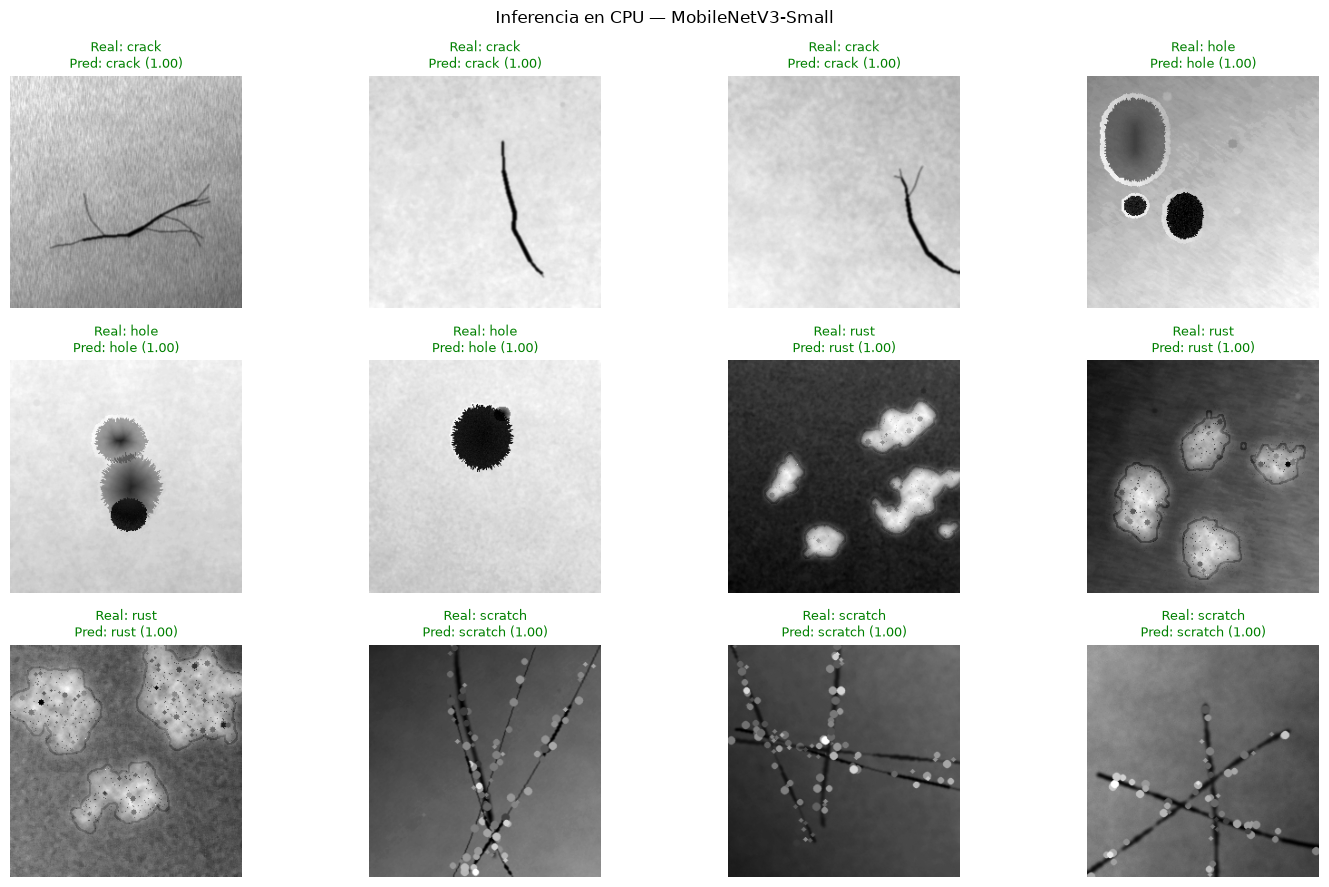

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9))

for ax, r in zip(axes.ravel(), resultados):
    ax.imshow(r["imagen"], cmap="gray")
    correcto = r["prediccion"] == r["real"]
    color = "green" if correcto else "red"
    ax.set_title(
        f"Real: {r['real']}\nPred: {r['prediccion']} ({r['confianza']:.2f})",
        fontsize=9,
        color=color,
    )
    ax.axis("off")

plt.suptitle("Inferencia en CPU — MobileNetV3-Small")
plt.tight_layout()
plt.show()

## 6. Inferencia del detector YOLO en CPU

El detector YOLOv8n (Sección 15 de `entrenar_modelos.ipynb`) localiza cada
defecto con su bounding box. Aquí se carga el checkpoint ya entrenado desde
`outputs/yolo/train/weights/best.pt` y se fuerza la ejecución en CPU.

In [6]:
from ultralytics import YOLO

# Pesos del detector ya entrenado (Sección 15 de entrenar_modelos.ipynb),
# guardados en outputs/ como exige la rúbrica.
YOLO_BEST_PT = ROOT / "outputs" / "yolo" / "train" / "weights" / "best.pt"
assert YOLO_BEST_PT.exists(), f"No existe {YOLO_BEST_PT}"

# Ultralytics carga en CPU por defecto cuando no hay GPU; se fuerza explícitamente
# con device="cpu" en predict() (equivalente a map_location="cpu").
yolo_model = YOLO(str(YOLO_BEST_PT))

print("CUDA disponible:", torch.cuda.is_available())
print("Detector cargado desde:", YOLO_BEST_PT)

CUDA disponible: False
Detector cargado desde: G:\Maestria\Modulo 9\Proyecto Final\outputs\yolo\train\weights\best.pt


Se corre la detección en CPU sobre las mismas 12 imágenes de
`notebooks/Imagenes_de_prueba/`. Cada caja dibujada indica el tipo de
defecto localizado y su confianza.

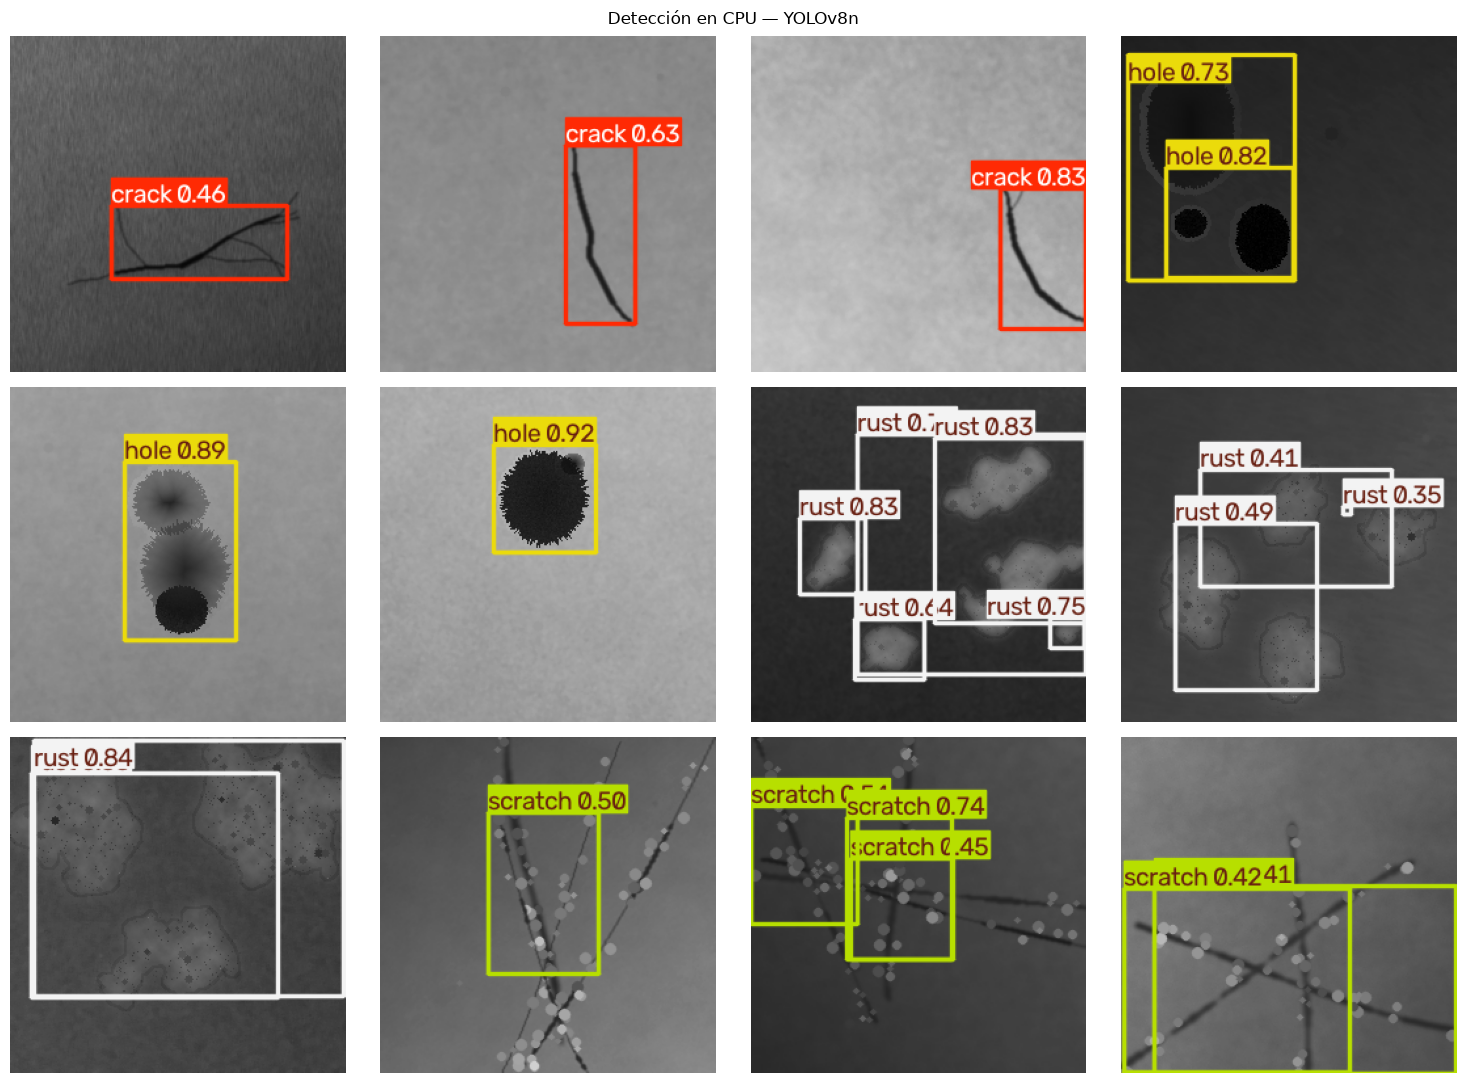

In [7]:
# Las mismas imágenes de prueba usadas con el clasificador.
yolo_test_imgs = sorted(PRUEBAS_DIR.glob("*.png"))

# Detección en CPU (device="cpu" explícito).
yolo_pred = yolo_model.predict(
    source=yolo_test_imgs,
    imgsz=256,
    device="cpu",
    conf=0.35,
    save=False,
    verbose=False,
)

fig, axes = plt.subplots(3, 4, figsize=(15, 11))
for ax, res in zip(axes.ravel(), yolo_pred):
    ax.imshow(res.plot())   # imagen con las cajas dibujadas
    ax.axis("off")

plt.suptitle("Detección en CPU — YOLOv8n")
plt.tight_layout()
plt.show()

## 7. Conclusión

Ambos modelos corren íntegramente en CPU:

- **Clasificador** (MobileNetV3-Small): carga de pesos con `map_location="cpu"`,
  preprocesamiento idéntico al del entrenamiento (`src/common.py`) y predicción
  correcta sobre imágenes nunca vistas.
- **Detector** (YOLOv8n): carga de `outputs/yolo/train/weights/best.pt` y
  detección con `device="cpu"`, dibujando la caja y la clase de cada defecto.

Para inferencia desde la línea de comandos (también CPU por defecto):

```bash
# Clasificador
python src/predict.py --modelo outputs/checkpoints/mobilenet_v3_small_best.pt \
    --imagen industrial_defect_dataset/test/crack/

# Detector (YOLO, vía CLI de Ultralytics)
yolo predict model=outputs/yolo/train/weights/best.pt \
    source=yolo_dataset/test/images/ device=cpu
```